In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import missingno as msno
import joblib

# Establish Country & Pollutant

In [2]:
load_dotenv()

True

In [3]:
POLLUTANT = "SO2"

In [4]:
COUNTRY_CODE = os.getenv("COUNTRY_CODE")  
RESULTS_SAVE_FOLDER = os.getenv("RESULTS_SAVE_FOLDER")

In [5]:
RUN_ID = f"{COUNTRY_CODE}_{POLLUTANT}"

output_dir = Path(RESULTS_SAVE_FOLDER) / f"Results_{RUN_ID}"
output_dir.mkdir(parents=True, exist_ok=True)

# Load Data

In [6]:
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [7]:
table_name = f"air_quality_{COUNTRY_CODE}"

In [8]:
query = f"""
SELECT * FROM {table_name} 
WHERE "Pollutant" = 1;
"""

df= pd.read_sql_query(query, engine)

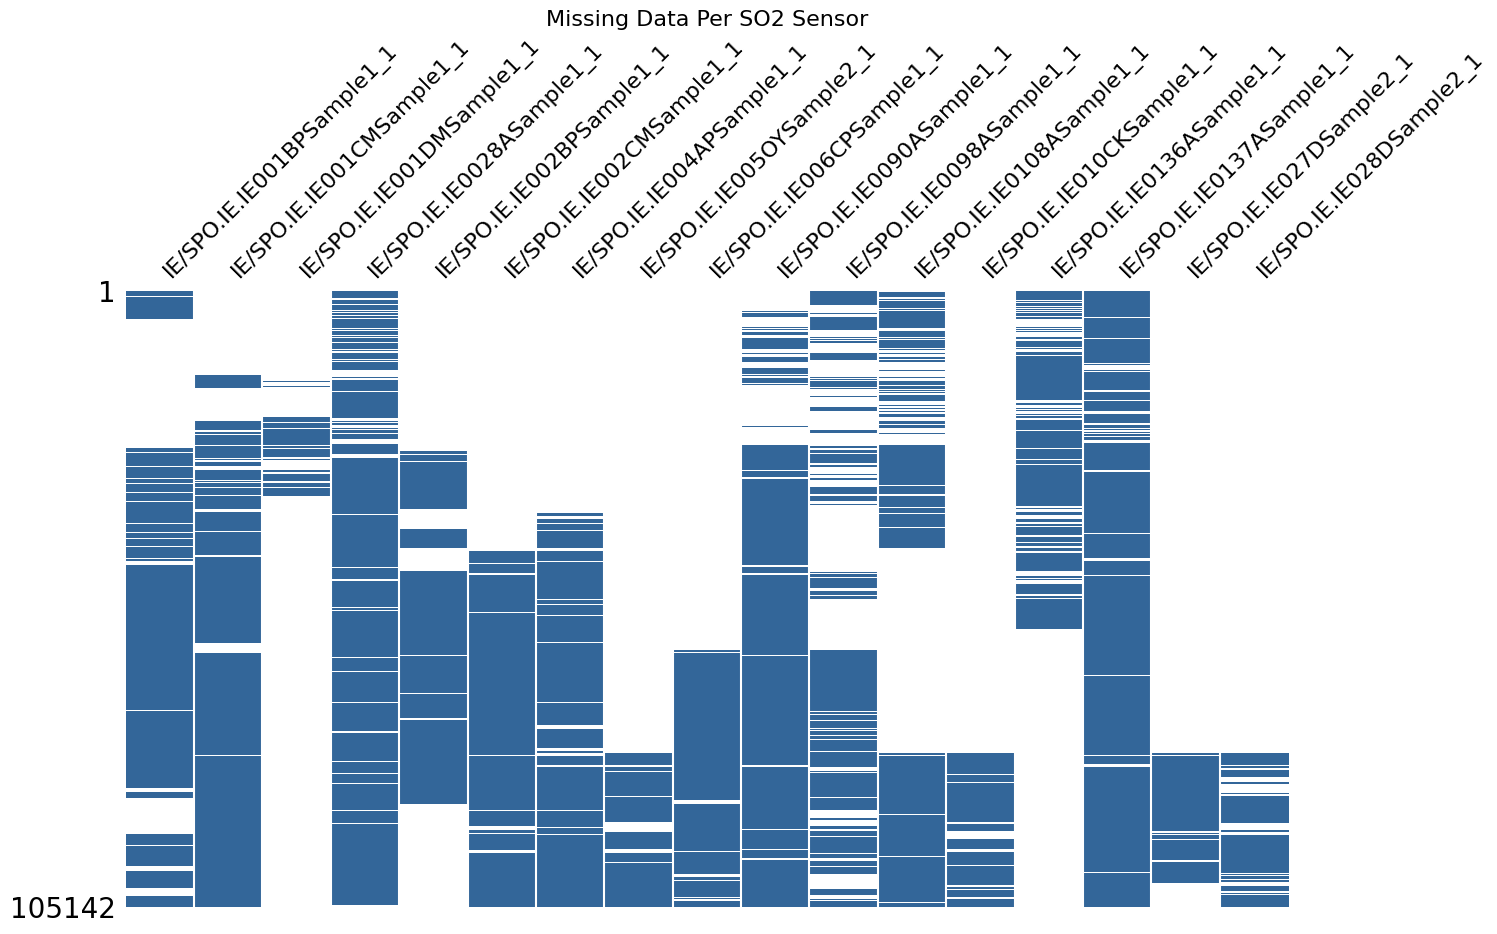

Longest continuous NaN streaks per SO2 Station:
Samplingpoint
IE/SPO.IE.IE0136ASample1_1    38665
IE/SPO.IE.IE001BPSample1_1    21728
IE/SPO.IE.IE002BPSample1_1    17519
IE/SPO.IE.IE0098ASample1_1    11069
IE/SPO.IE.IE001DMSample1_1     8785
IE/SPO.IE.IE027DSample2_1      4174
IE/SPO.IE.IE004APSample1_1     2905
IE/SPO.IE.IE0090ASample1_1     2456
IE/SPO.IE.IE005OYSample2_1     1791
IE/SPO.IE.IE001CMSample1_1     1618
Name: Value, dtype: int64


In [9]:
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

df_pivot = df.pivot_table(index='Start', columns='Samplingpoint', values='Value') # pivot the data to get a matrix of sampling points vs time, with the values being the pollutant measurements.

# Visualize the missing data gaps per sensor with msno matrix to show presence and absence of data
msno.matrix(df_pivot, figsize=(15, 8), color=(0.2, 0.4, 0.6), sparkline=False)
plt.title(f"Missing Data Per {POLLUTANT} Sensor", fontsize=16)
plt.savefig(output_dir / f"{RUN_ID}_msno_matrix.png", bbox_inches='tight')
plt.show()
plt.close()
# longest streak of missing data
def max_consecutive_nans(series):
    is_na = series.isna()
    # Cumulatively (cumsum) sum the non-NaNs to create unique group IDs for consecutive NaNs
    return is_na.groupby((~is_na).cumsum()).sum().max()

longest_nan_streaks = df.groupby('Samplingpoint')['Value'].apply(max_consecutive_nans) 
longest_nan_streaks = longest_nan_streaks.sort_values(ascending=False)

print(f"Longest continuous NaN streaks per {POLLUTANT} Station:")
print(longest_nan_streaks.head(10))

In [10]:
df['Start'] = pd.to_datetime(df['Start'])

In [11]:
print(f"Rows in dataset: {len(df)}")
print(f"NaN rows in dataset: {df['Value'].isna().sum()}")
print(f"Non-NaN rows in dataset: {df['Value'].notna().sum()}")
df.head()

Rows in dataset: 1167055
NaN rows in dataset: 278037
Non-NaN rows in dataset: 889018


,Samplingpoint,Pollutant,Start,End,Value,Unit,AggType,Validity,Verification,ResultTime,DataCapture,Quality_Flag
0,IE/SPO.IE.IE001BPSample1_1,1,2013-01-01 01:00:00,2013-01-01 02:00:00,5.054000,ug.m-3,hour,1,1,2014-09-30 21:12:46,NaN,Good
1,IE/SPO.IE.IE001BPSample1_1,1,2013-01-01 02:00:00,2013-01-01 03:00:00,6.206665,ug.m-3,hour,1,1,2014-09-30 21:12:46,NaN,Good
2,IE/SPO.IE.IE001BPSample1_1,1,2013-01-01 03:00:00,2013-01-01 04:00:00,5.652500,ug.m-3,hour,1,1,2014-09-30 21:12:46,NaN,Good
3,IE/SPO.IE.IE001BPSample1_1,1,2013-01-01 04:00:00,2013-01-01 05:00:00,5.054000,ug.m-3,hour,1,1,2014-09-30 21:12:46,NaN,Good
4,IE/SPO.IE.IE001BPSample1_1,1,2013-01-01 05:00:00,2013-01-01 06:00:00,5.519500,ug.m-3,hour,1,1,2014-09-30 21:12:46,NaN,Good


# Clean Data & Fill gaps when it makes sense to do so

In [12]:
print(f"Total NaN readings after removing data collection errors: {df['Value'].isna().sum()}")

Total NaN readings after removing data collection errors: 278037


In [13]:
df_unified = df.copy() # due to using samplingpoint (previosuly split it up into staionid and sample) this si to work with my code.

In [14]:
def apply_hourly_interpolation(group): # Time-weighted linear interpolation with a 3 hour limit
    
    # Enforce a continuous hourly timeline, required for time-based interpolation
    group = group.set_index('Start').resample('h').asfreq()# asfreq() creates new rows for missing hours with NaN values
    
    group['Value'] = group['Value'].interpolate(method='time', limit=3) 
    
    # Return ONLY the Value column Pandas will automatically re-attach the Samplingpoint
    return group[['Value']]

In [15]:
# Apply interpolation
df_hourly = df_unified.groupby('Samplingpoint').apply(apply_hourly_interpolation).reset_index()

print(f"Hourly dataset size after resampling and patching: {len(df_hourly)}") # may have more rows due to .resample('h').asfreq() filling in missing hours with NaNs
print(f"Remaining NaNs to handle later: {df_hourly['Value'].isna().sum()}")
df_hourly.head(10)

Hourly dataset size after resampling and patching: 1280239
Remaining NaNs to handle later: 369699


,Samplingpoint,Start,Value
0,IE/SPO.IE.IE001BPSample1_1,2013-01-01 01:00:00,5.054000
1,IE/SPO.IE.IE001BPSample1_1,2013-01-01 02:00:00,6.206665
2,IE/SPO.IE.IE001BPSample1_1,2013-01-01 03:00:00,5.652500
3,IE/SPO.IE.IE001BPSample1_1,2013-01-01 04:00:00,5.054000
4,IE/SPO.IE.IE001BPSample1_1,2013-01-01 05:00:00,5.519500
5,IE/SPO.IE.IE001BPSample1_1,2013-01-01 06:00:00,6.051500
6,IE/SPO.IE.IE001BPSample1_1,2013-01-01 07:00:00,5.253500
7,IE/SPO.IE.IE001BPSample1_1,2013-01-01 08:00:00,5.652500
8,IE/SPO.IE.IE001BPSample1_1,2013-01-01 09:00:00,4.189500
9,IE/SPO.IE.IE001BPSample1_1,2013-01-01 10:00:00,4.921000


# Aggregation & Fill in gaps when possible

In [16]:
def aggregate_to_daily(station_group): # Houly to daily aggregation with a minimum 75% of valid data (18 hour)

    station_group = station_group.set_index('Start') # Temp index for resampling
    
    # Resample to daily, calculate mean and the count of valid hours
    daily_stats = station_group['Value'].resample('D').agg(
        Daily_Value='mean', 
        Valid_Hours='count'
    )
    
    # if less than 18 hours valid set daily to NaN
    daily_stats.loc[daily_stats['Valid_Hours'] < 18, 'Daily_Value'] = np.nan
    
    # Drop the Valid_Hours column and rename back to 'Value'
    return daily_stats[['Daily_Value']].rename(columns={'Daily_Value': 'Value'})

In [17]:
# Apply agg per station
df_daily = df_hourly.groupby('Samplingpoint').apply(aggregate_to_daily).reset_index()

print(f"Aggregated to {len(df_daily)} daily rows.")
print(f"Days that are NaN including days with less than 75% data: {df_daily['Value'].isna().sum()}")
df_daily.head()

Aggregated to 53344 daily rows.
Days that are NaN including days with less than 75% data: 16270


,Samplingpoint,Start,Value
0,IE/SPO.IE.IE001BPSample1_1,2013-01-01,4.919072
1,IE/SPO.IE.IE001BPSample1_1,2013-01-02,4.570028
2,IE/SPO.IE.IE001BPSample1_1,2013-01-03,4.116535
3,IE/SPO.IE.IE001BPSample1_1,2013-01-04,3.341625
4,IE/SPO.IE.IE001BPSample1_1,2013-01-05,3.654729


In [18]:
# Daily Time weighted linear interpolation, 2 missing days max
def apply_daily_interpolation(station_group):
    station_group = station_group.set_index('Start') # Make Datetime index again for Pd

    station_group['Value'] = station_group['Value'].interpolate(method='time', limit=2)
    return station_group[['Value']]

In [19]:
# Apply the interpolation per station
df_daily_Final = df_daily.groupby('Samplingpoint').apply(apply_daily_interpolation).reset_index()

print(f"Dataset size after coverting to daily and interpolation: {len(df_daily_Final)}")
print(f"Remaining persistent NaNs with gaps for than 2 days: {df_daily_Final['Value'].isna().sum()}")
df_daily_Final.head()

Dataset size after coverting to daily and interpolation: 53344
Remaining persistent NaNs with gaps for than 2 days: 14746


,Samplingpoint,Start,Value
0,IE/SPO.IE.IE001BPSample1_1,2013-01-01,4.919072
1,IE/SPO.IE.IE001BPSample1_1,2013-01-02,4.570028
2,IE/SPO.IE.IE001BPSample1_1,2013-01-03,4.116535
3,IE/SPO.IE.IE001BPSample1_1,2013-01-04,3.341625
4,IE/SPO.IE.IE001BPSample1_1,2013-01-05,3.654729


# Saving Cleaned Data

In [20]:
target_folder = os.getenv("BASE_DATA_PATH") # target folder saved in .env

# Dynamically naming country and polulutant for auto name and save
file_name = f"{COUNTRY_CODE}_{POLLUTANT}_Daily_Cleaned.parquet"
file_path = os.path.join(target_folder, file_name)

df_daily_Final.to_parquet(file_path, index=False) # save cleaned data as parquet

# Summary of Data Preperation/Analysis

In [28]:
# Hourly & Daily Data Analysis Summary
total_bad_rows = (df['Quality_Flag'] != 'Good').sum()
print(f"Total rows cleaned/changed from DataToDatabase Script: {total_bad_rows}")

print("Summary of Important Data")
print("Hourly Changes")

print(f"Total BAD Rows the Data Cleaning removes ans sets to NAN, that were caused by data colelction/sensor issues: {total_bad_rows}")
print(f"Good Hourly Rows (Non Nan) Before cleaning: {df['Value'].notna().sum()}")
print(f"Total Good Hourly Rows (Non Nan) After cleaning: {df_hourly['Value'].notna().sum()}")
print(f"Increase in good Hourly rows as a reuslt from cleaning: {df_hourly['Value'].notna().sum() - df['Value'].notna().sum()}")
print("Daily Changes")
print(f"Good Rows Daily(Non Nan) After aggregation (75% 18hour rule): {df_daily['Value'].notna().sum()}")
print(f"Total Good Daily (Non Nan) After aggregation & Interpolation (2 day max): {df_daily_Final['Value'].notna().sum()}")
print(f"Increase in good rows as a result of interpolation/cleaning: {df_daily_Final['Value'].notna().sum() - df_daily['Value'].notna().sum()}")

Total rows cleaned/changed from DataToDatabase Script: 278037
Summary of Important Data
Hourly Changes
Total BAD Rows the Data Cleaning removes ans sets to NAN, that were caused by data colelction/sensor issues: 278037
Good Hourly Rows (Non Nan) Before cleaning: 889018
Total Good Hourly Rows (Non Nan) After cleaning: 910540
Increase in good Hourly rows as a reuslt from cleaning: 21522
Daily Changes
Good Rows Daily(Non Nan) After aggregation (75% 18hour rule): 37074
Total Good Daily (Non Nan) After aggregation & Interpolation (2 day max): 38598
Increase in good rows as a result of interpolation/cleaning: 1524


# Before, During & After Plotted

In [22]:
print("Before Interpolation hourly (df_unified)")
print(f"Total NaNs: {df_unified['Value'].isna().sum()}")
print(df_unified['Value'].describe())

print("\nAfter Interpolation hourly (df_dhourly)")
print(f"Total NaNs: {df_hourly['Value'].isna().sum()}")
print(df_hourly['Value'].describe())

Before Interpolation hourly (df_unified)
Total NaNs: 278037
count    889018.000000
mean          3.638765
std           8.109848
min           0.000000
25%           1.064000
50%           2.128000
75%           3.724000
max        2525.975000
Name: Value, dtype: float64

After Interpolation hourly (df_dhourly)
Total NaNs: 369699
count    910540.000000
mean          3.594583
std           8.528881
min           0.000000
25%           1.064000
50%           2.075000
75%           3.724000
max        2525.975000
Name: Value, dtype: float64


In [23]:
print("Before Interpolation (df_daily)")
print(f"Total NaNs: {df_daily['Value'].isna().sum()}")
print(df_daily['Value'].describe())

print("\nAfter Interpolaton (df_daily_Final)")
print(f"Total NaNs: {df_daily_Final['Value'].isna().sum()}")
print(df_daily_Final['Value'].describe())

Before Interpolation (df_daily)
Total NaNs: 16270
count    37074.000000
mean         3.623583
std          5.980590
min          0.000000
25%          1.208083
50%          2.172333
75%          3.845917
max        264.840799
Name: Value, dtype: float64

After Interpolaton (df_daily_Final)
Total NaNs: 14746
count    38598.000000
mean         3.581010
std          5.947711
min          0.000000
25%          1.163750
50%          2.139695
75%          3.801583
max        264.840799
Name: Value, dtype: float64


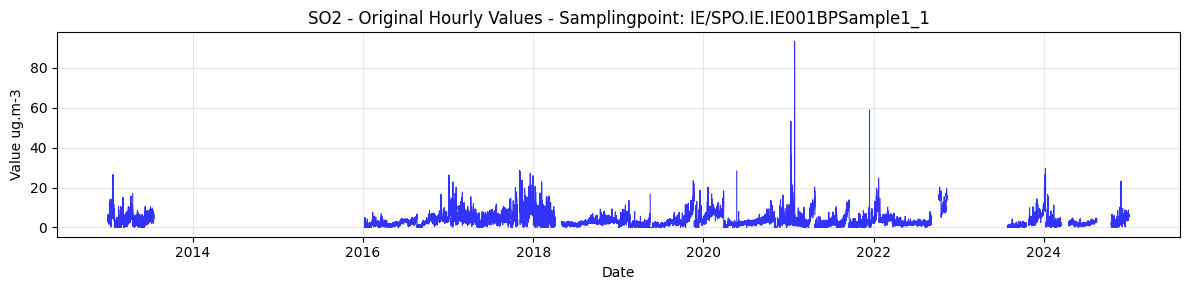

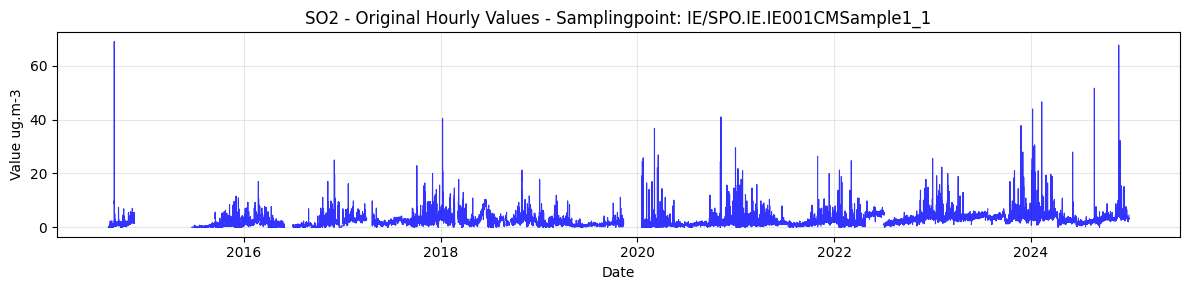

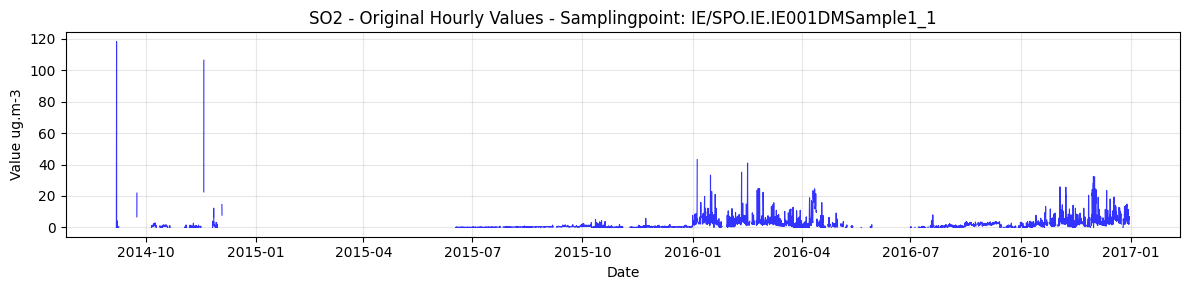

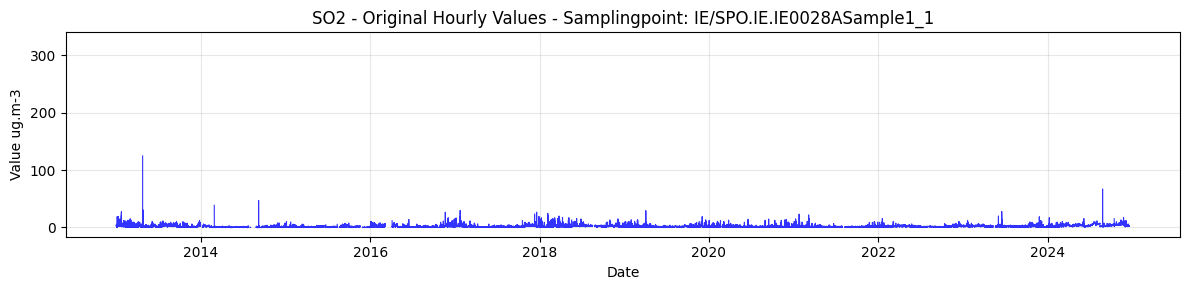

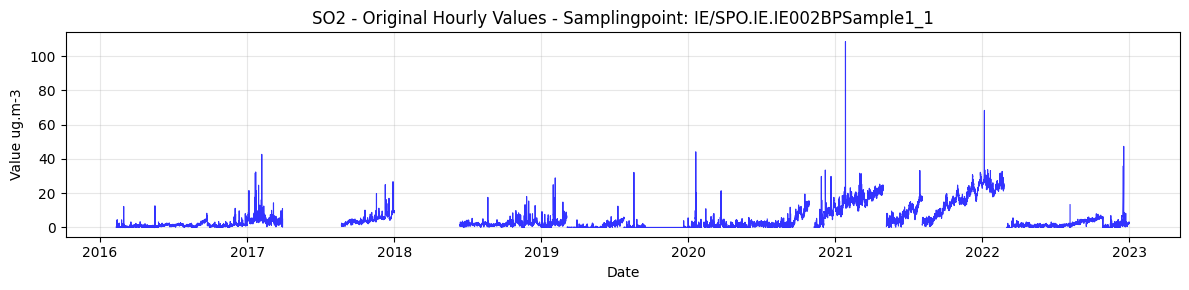

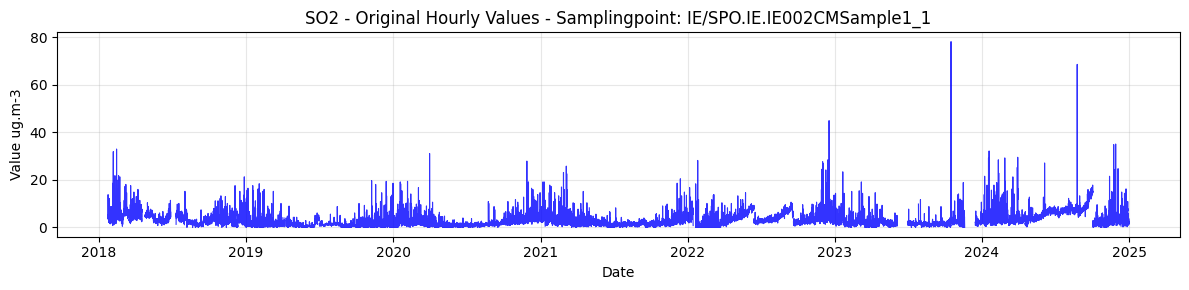

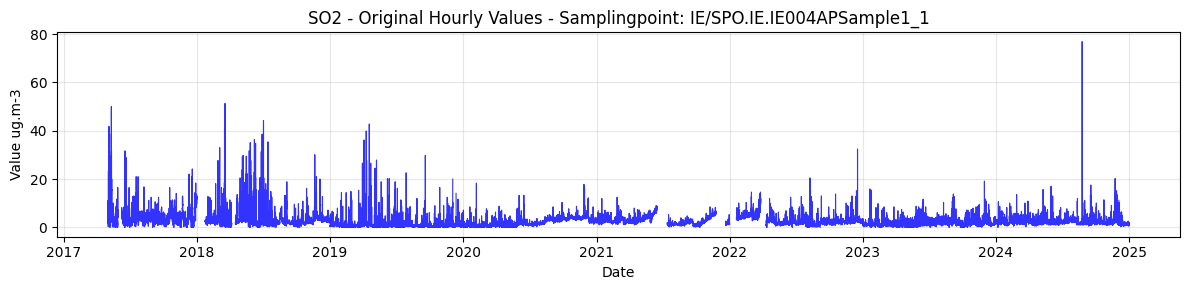

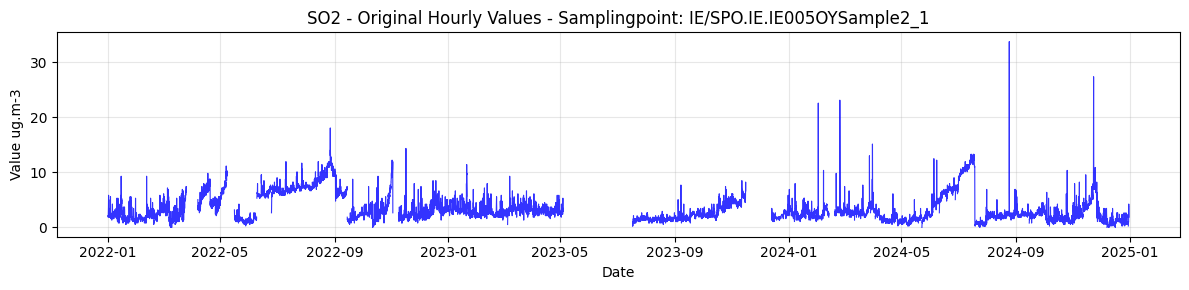

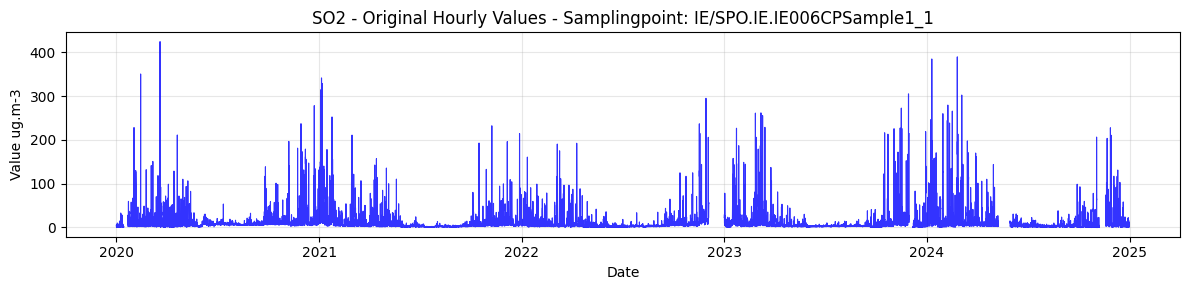

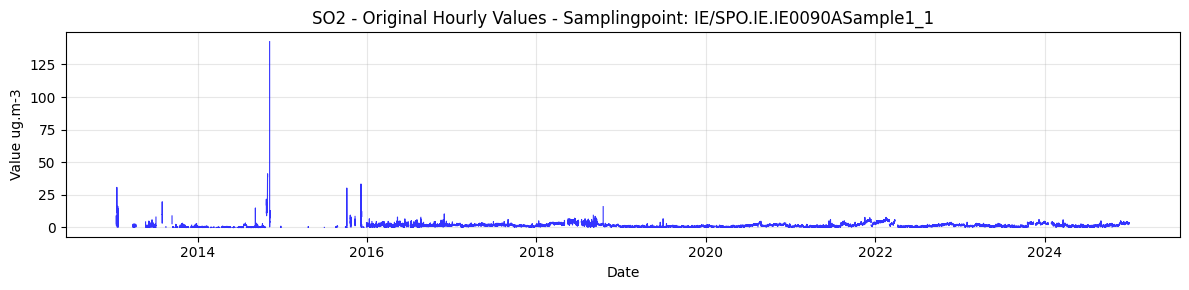

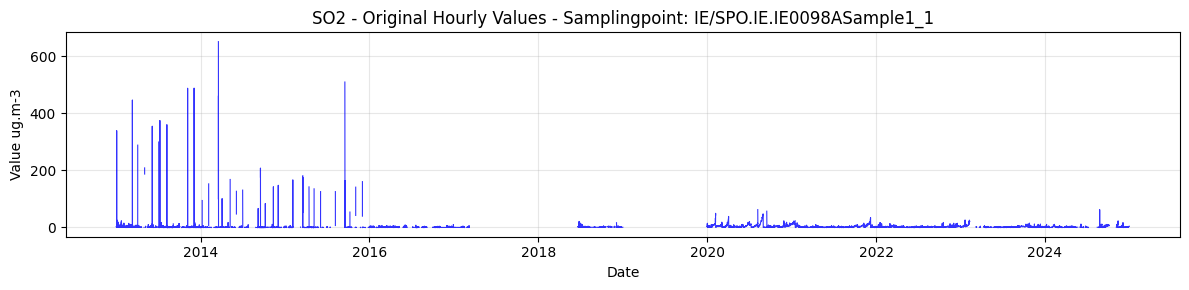

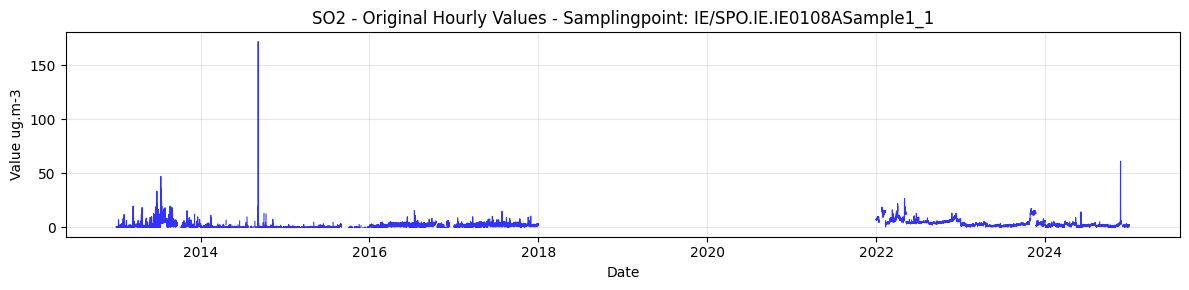

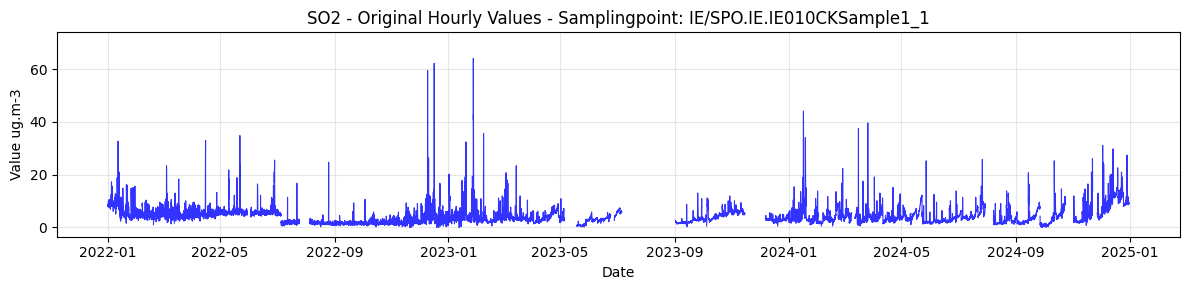

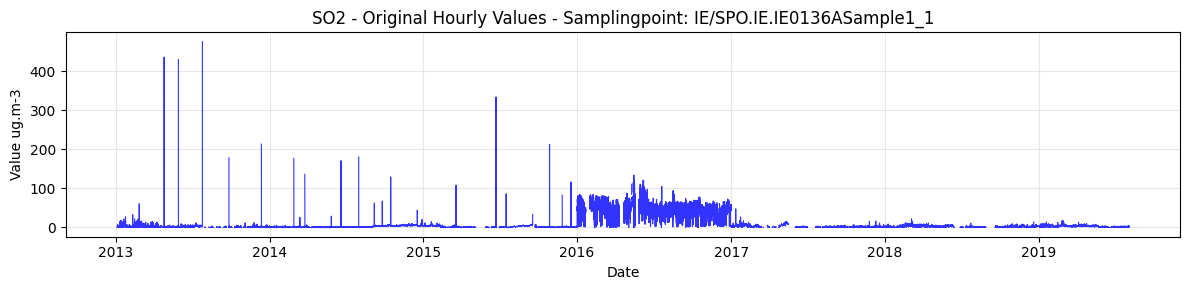

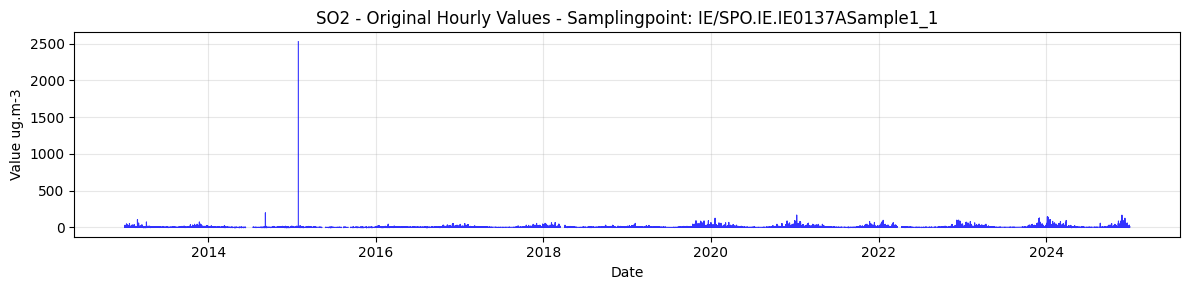

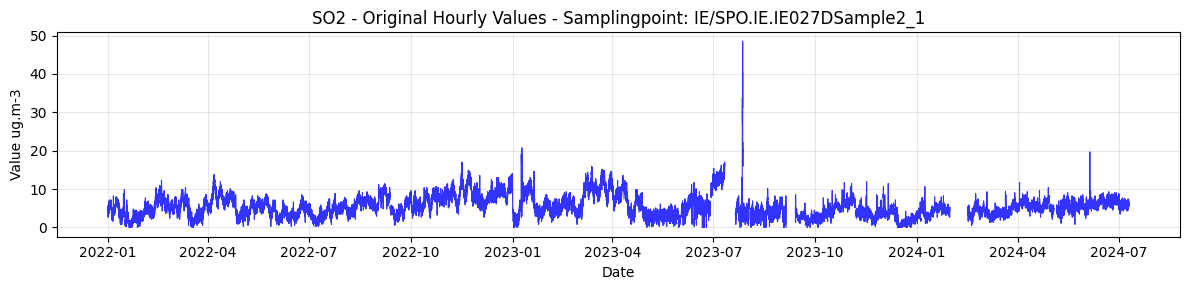

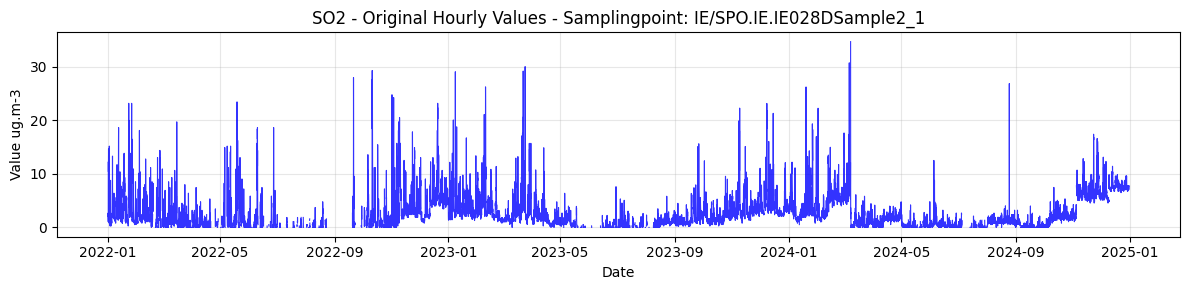

In [24]:
#Create a specific folder for these plots so they don't clutter your main directory
plot_dir = output_dir / "Original_Hourly_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_unified['Samplingpoint'].unique()

for station in stations:
    station_data = df_unified[df_unified['Samplingpoint'] == station]
    
   
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='blue', alpha=0.8, linewidth=0.8)

    plt.title(f'{POLLUTANT} - Original Hourly Values - Samplingpoint: {station}')
    plt.ylabel('Value ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Dynamic save for each plot in the loop
    # We clean the station name (replace dots/slashes with underscores) to avoid file errors
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_hourly.png"
    
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    
    plt.show() 
    plt.close() 

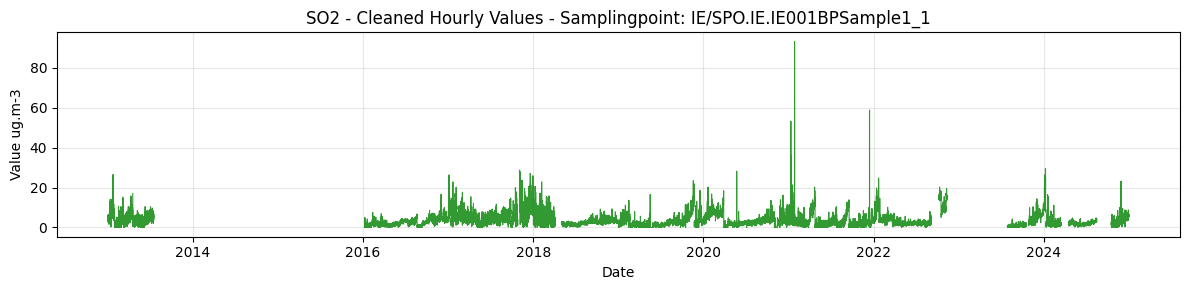

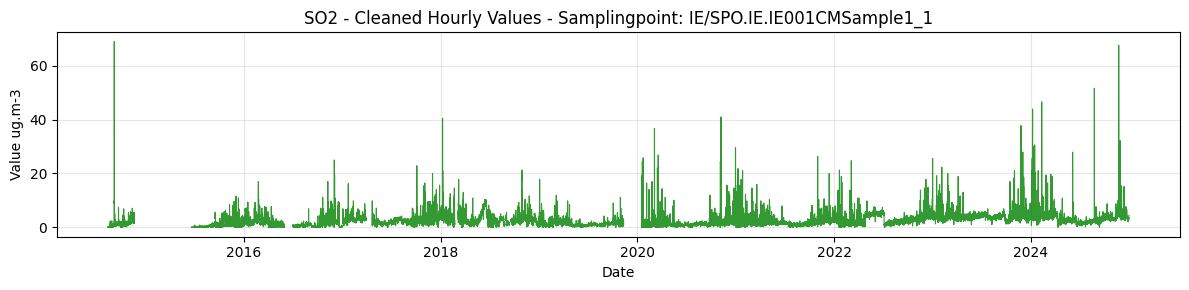

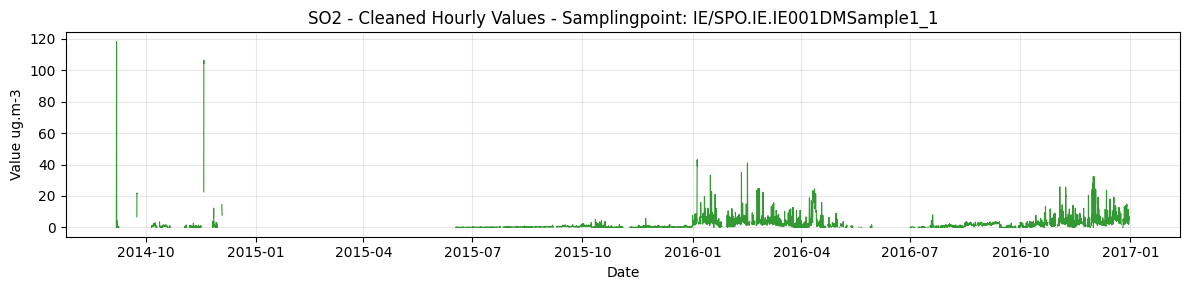

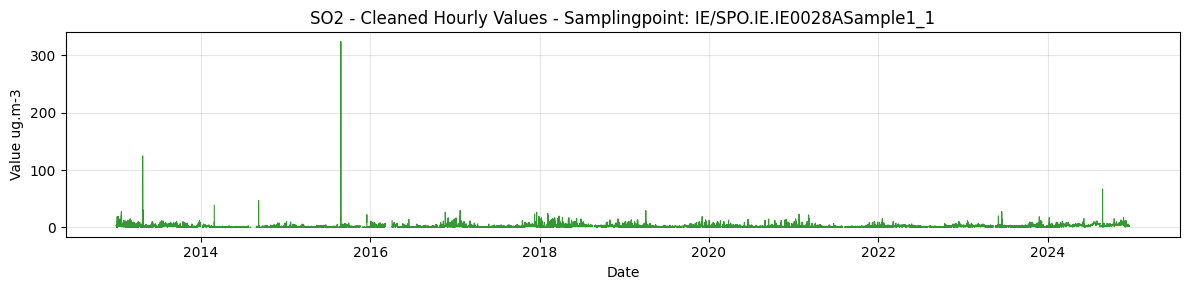

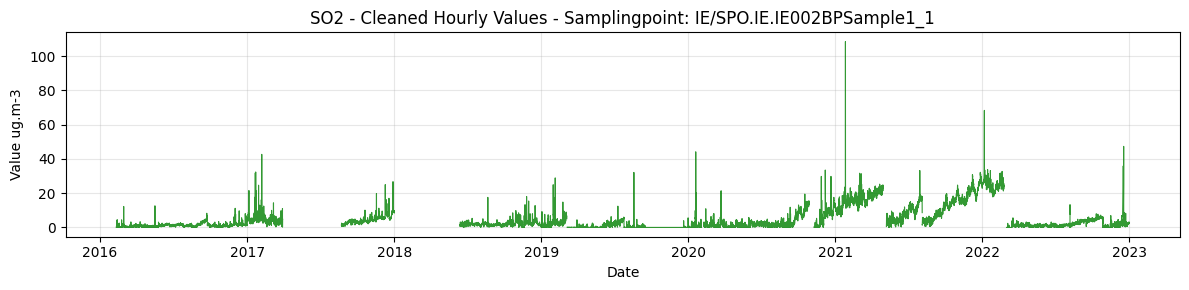

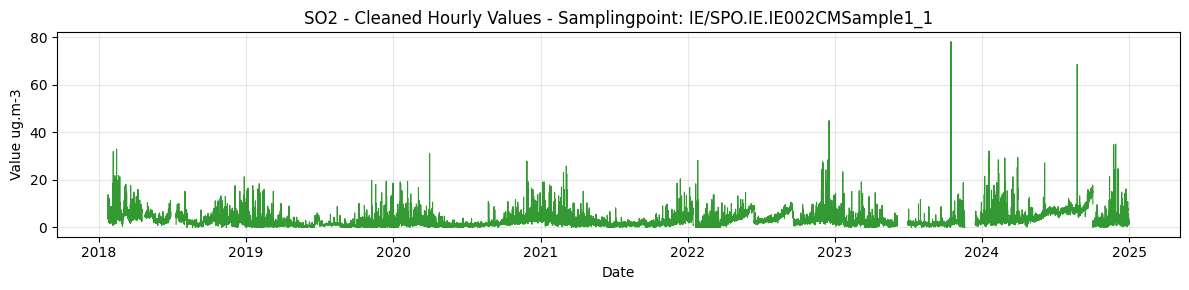

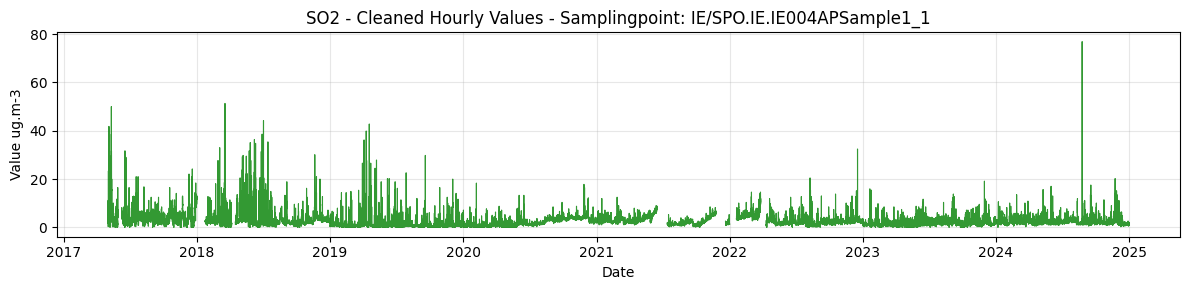

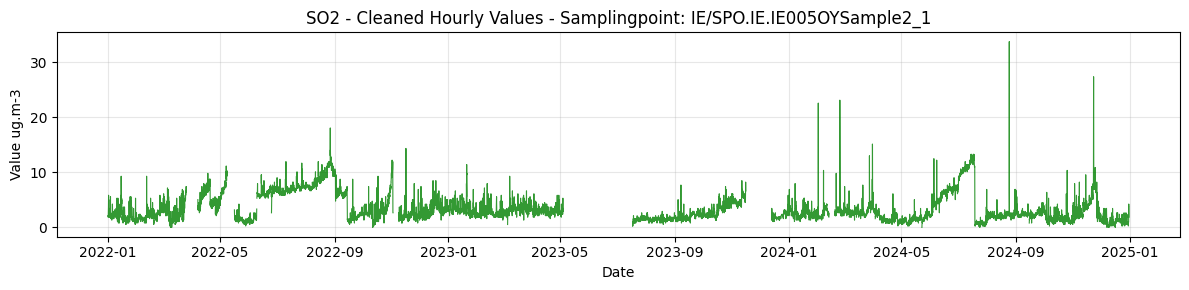

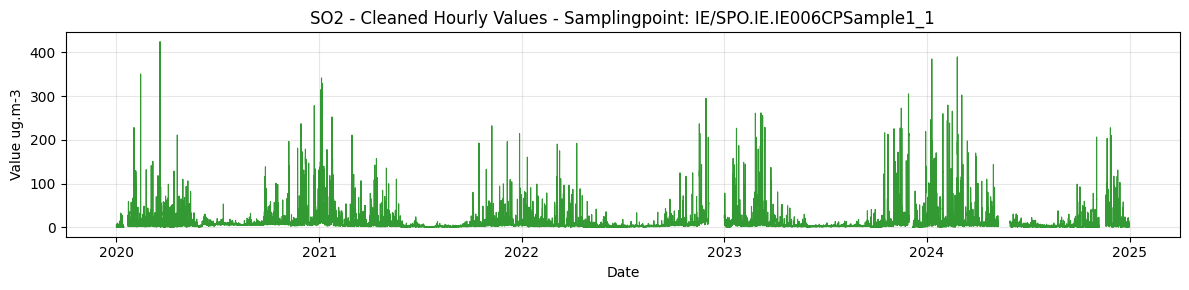

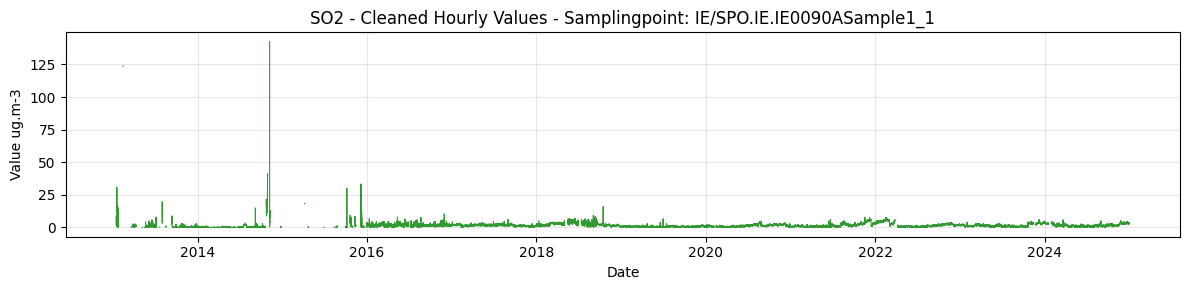

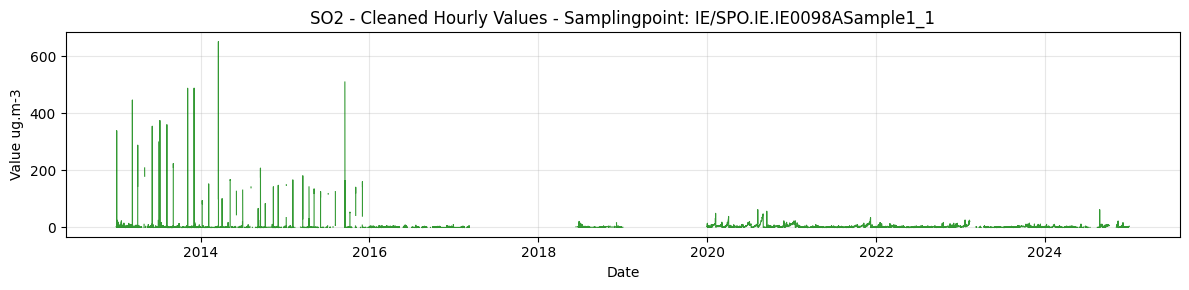

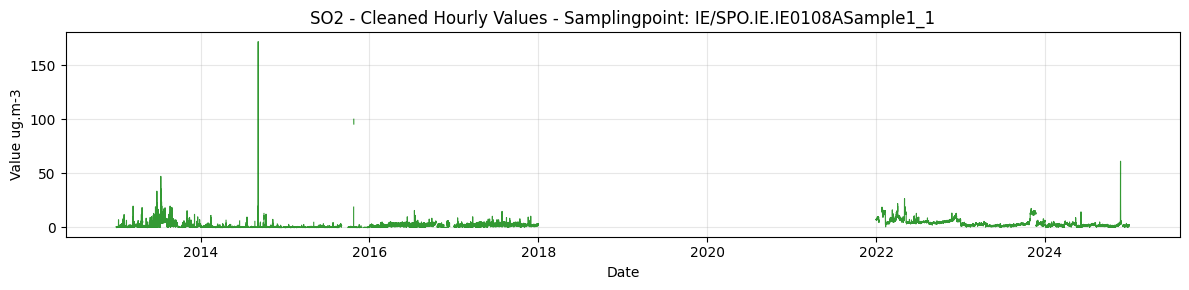

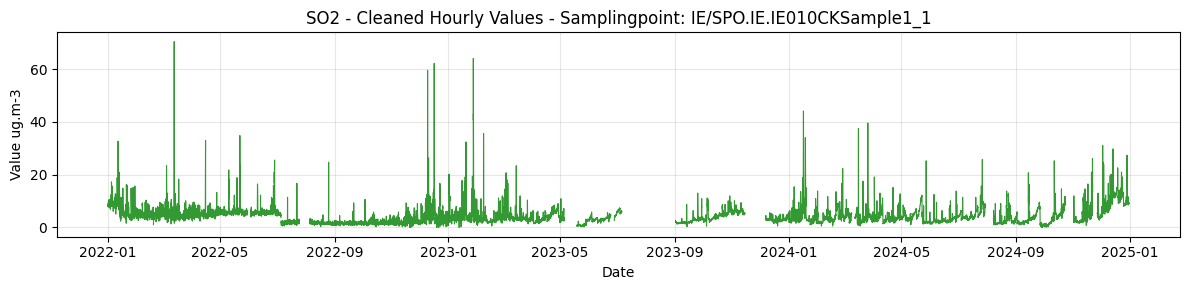

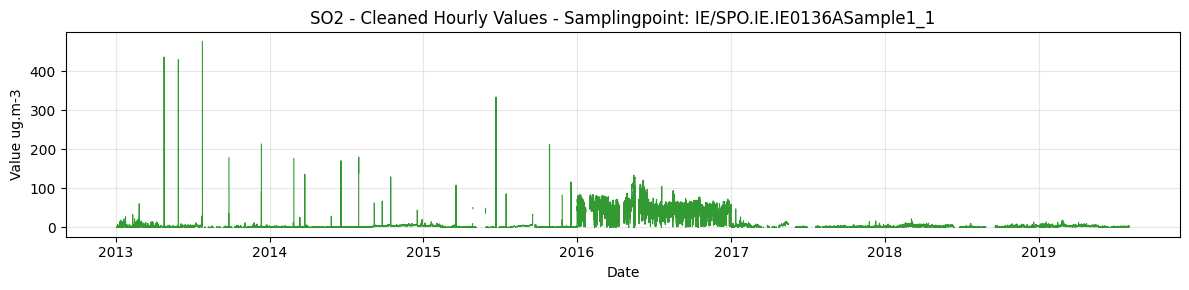

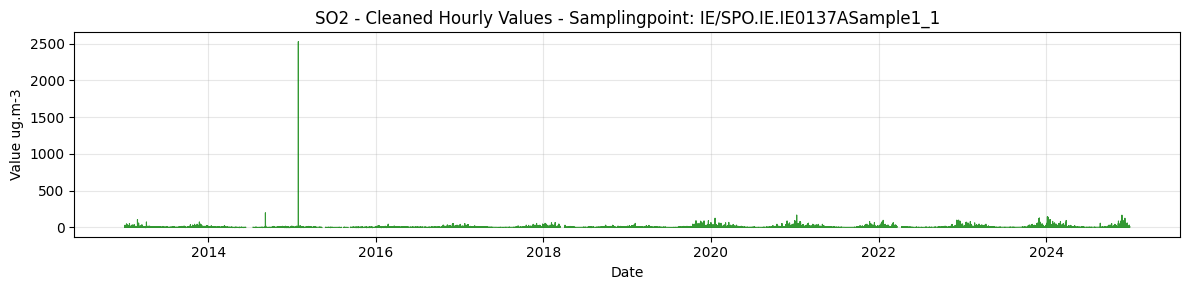

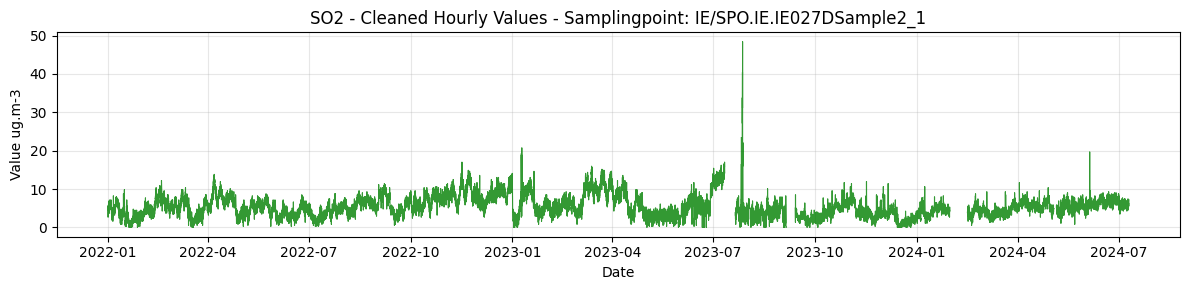

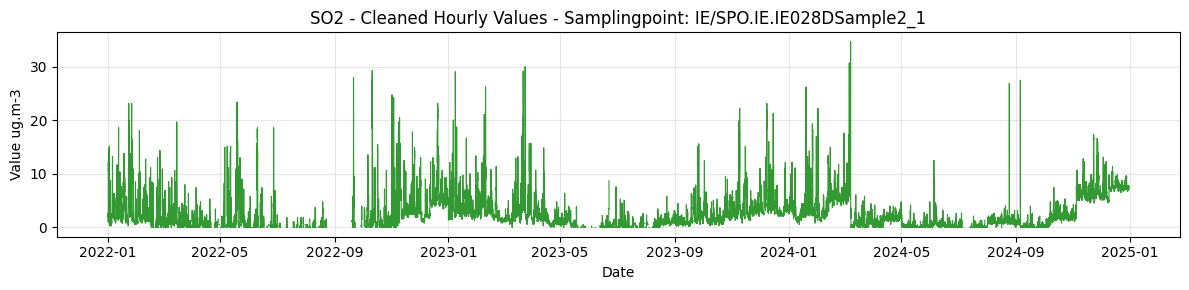

In [25]:
plot_dir = output_dir / "Cleaned_Hourly_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_hourly['Samplingpoint'].unique()

for station in stations:
    station_data = df_hourly[df_hourly['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='green', alpha=0.8, linewidth=0.8)
    plt.title(f'{POLLUTANT} - Cleaned Hourly Values - Samplingpoint: {station}')
    plt.ylabel('Value ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_cleaned_hourly.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.show()
    plt.close()

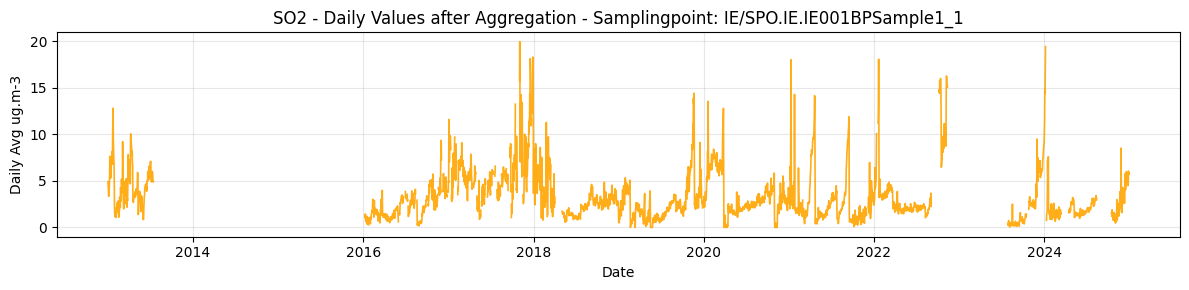

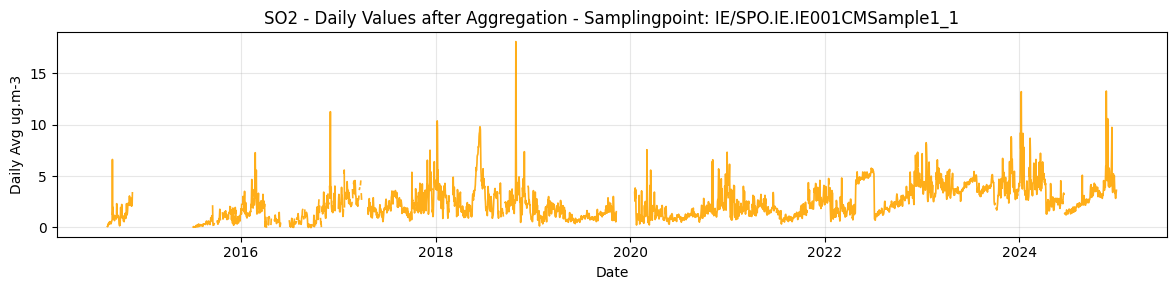

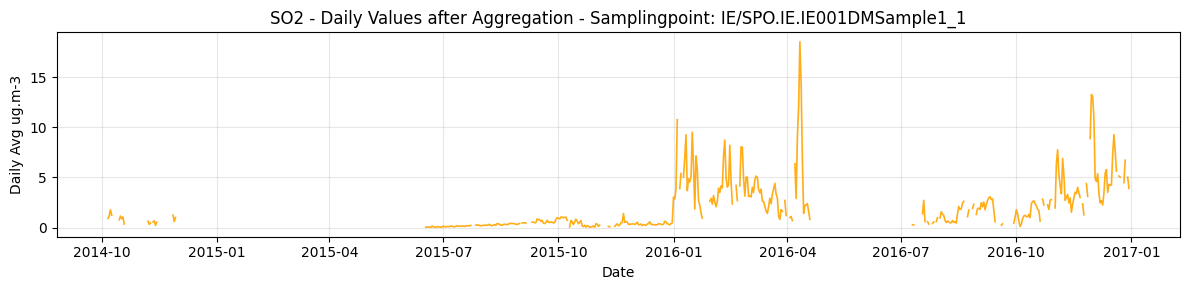

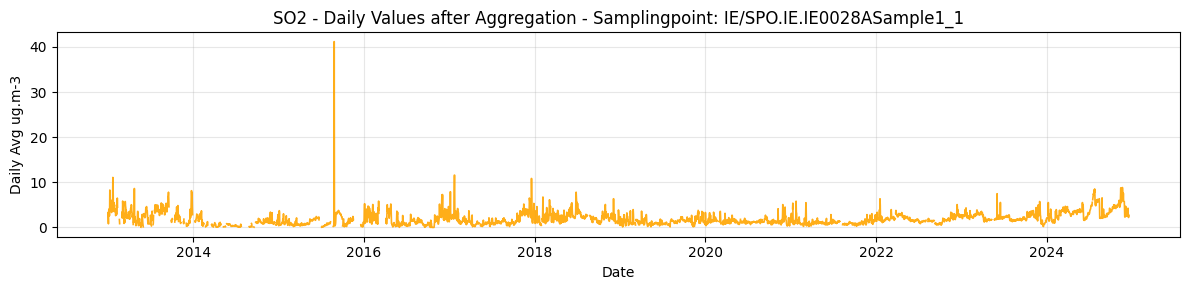

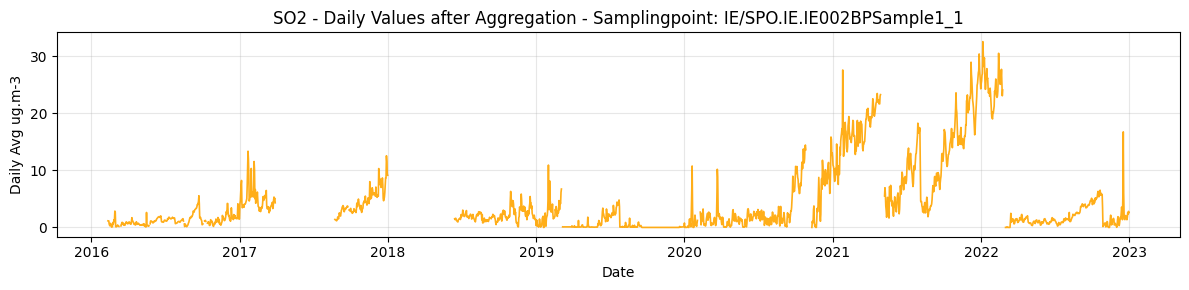

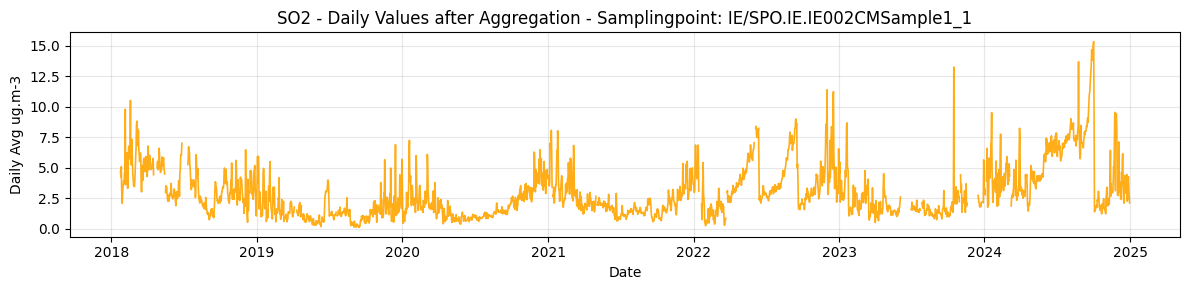

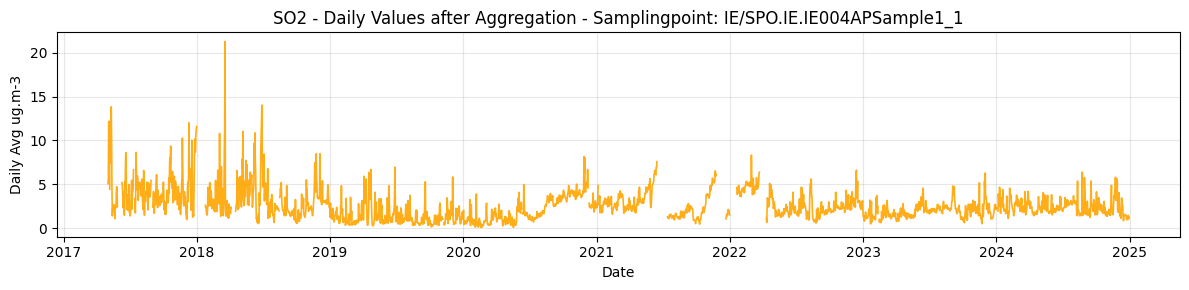

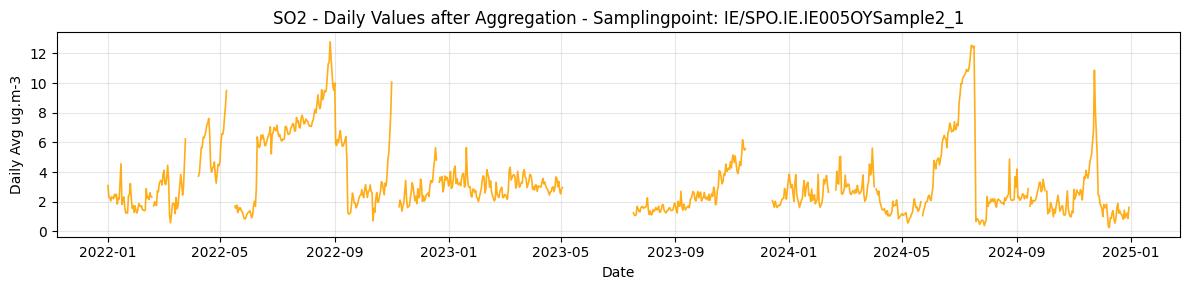

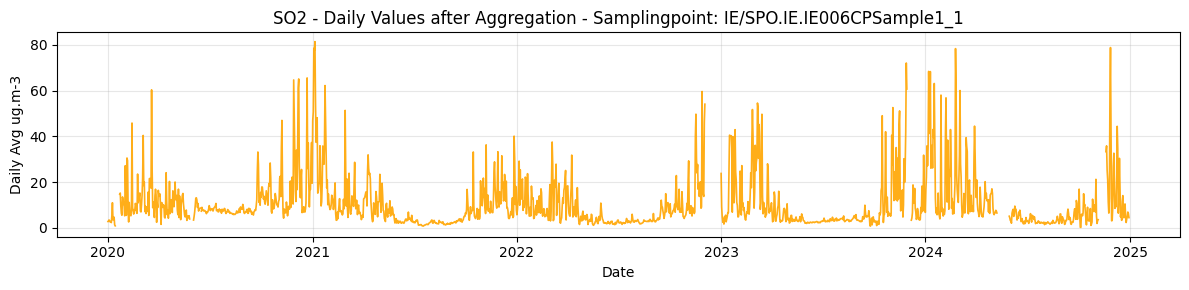

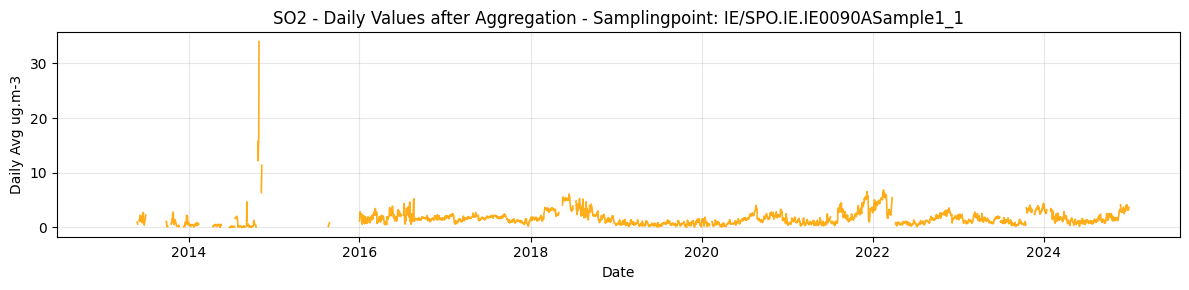

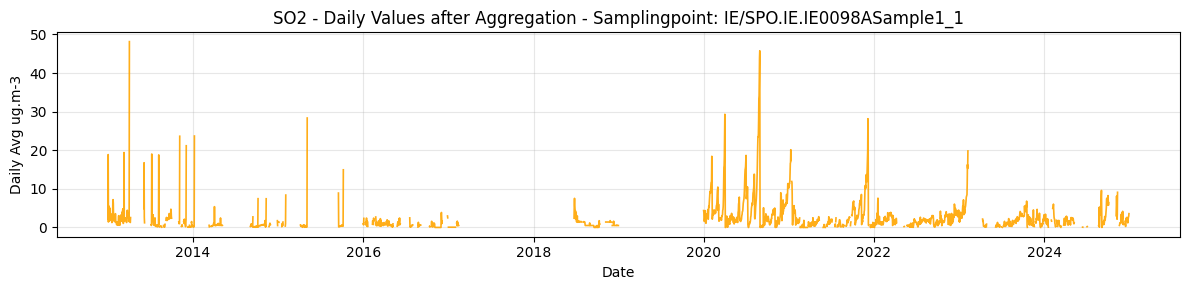

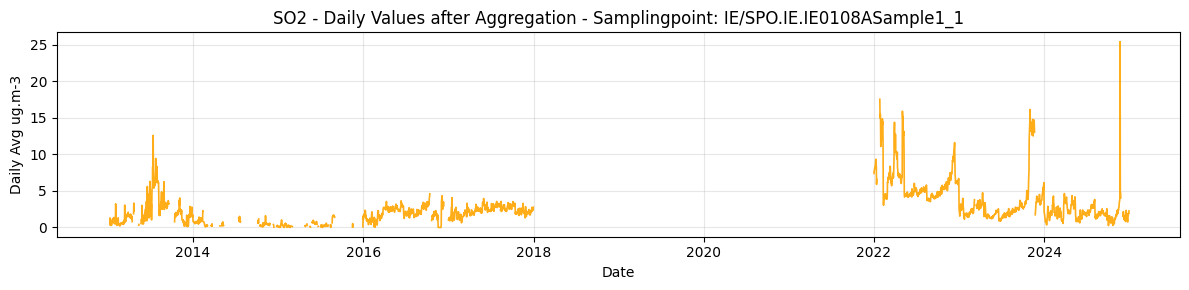

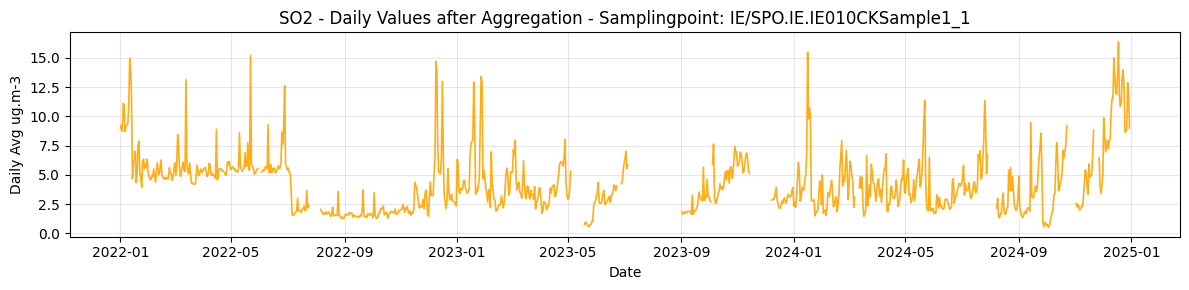

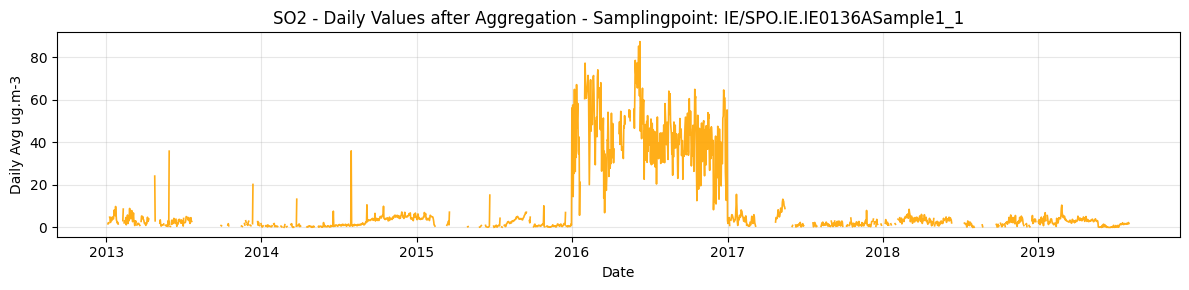

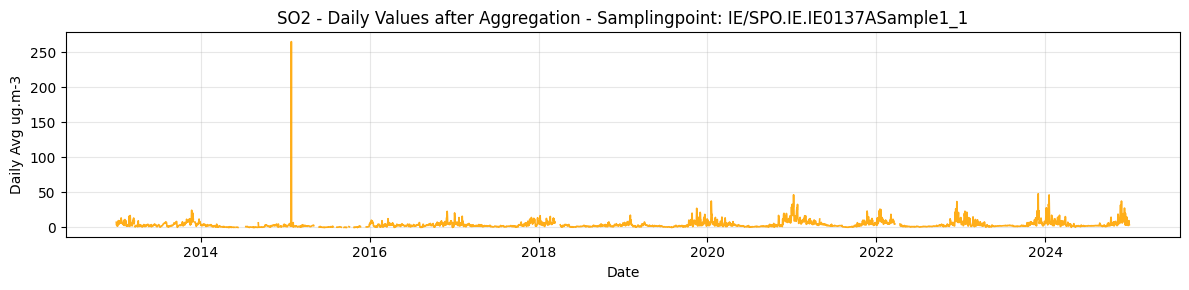

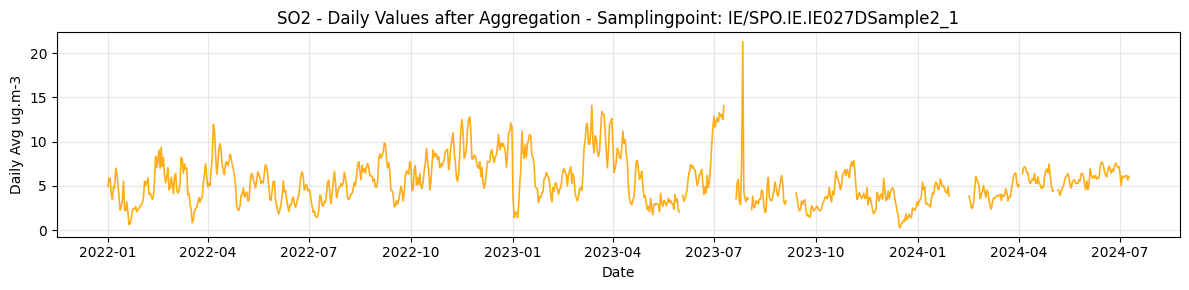

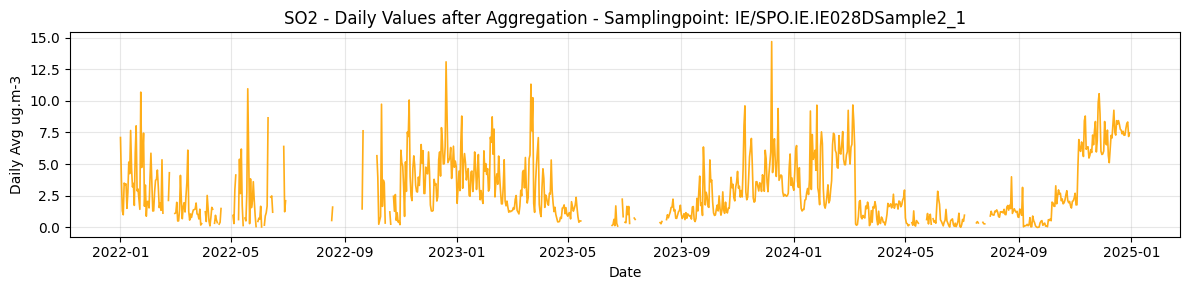

In [26]:
plot_dir = output_dir / "Daily_Aggregated_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_daily['Samplingpoint'].unique()

for station in stations:
    station_data = df_daily[df_daily['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='orange', alpha=0.9, linewidth=1.2)
    plt.title(f'{POLLUTANT} - Daily Values after Aggregation - Samplingpoint: {station}')
    plt.ylabel('Daily Avg ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_aggregated_daily.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.tight_layout()
    plt.show()
    plt.close()

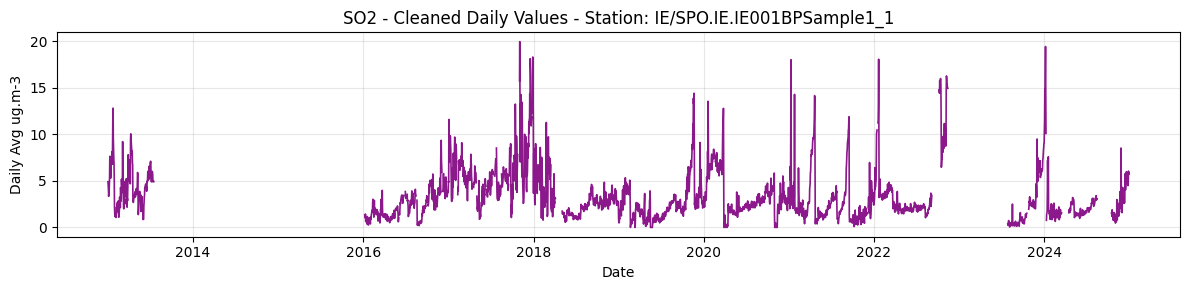

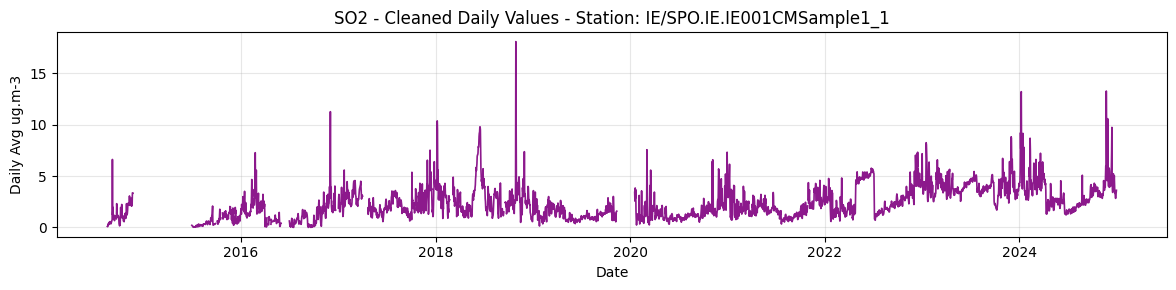

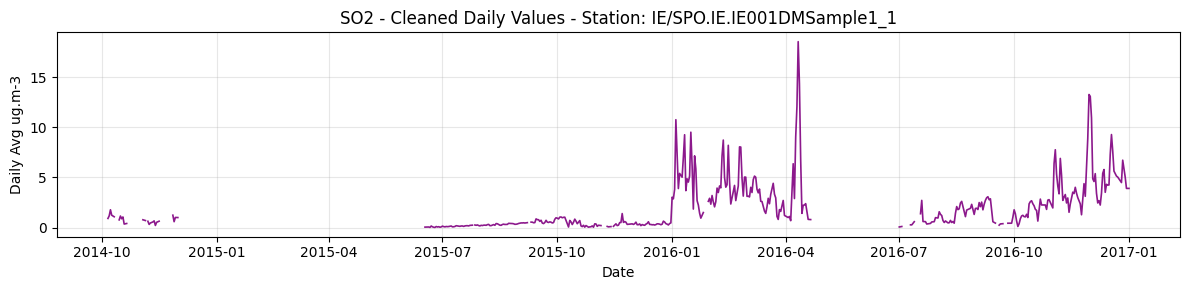

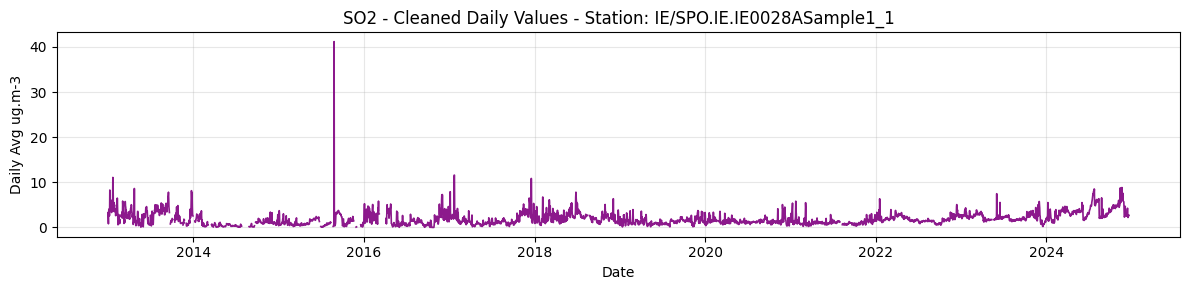

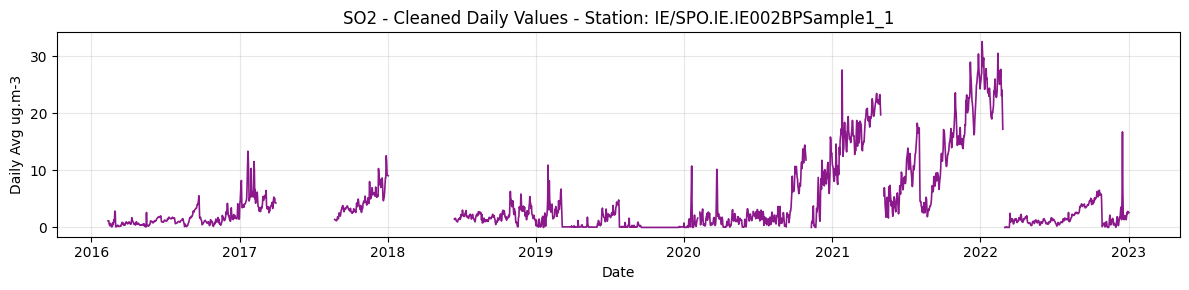

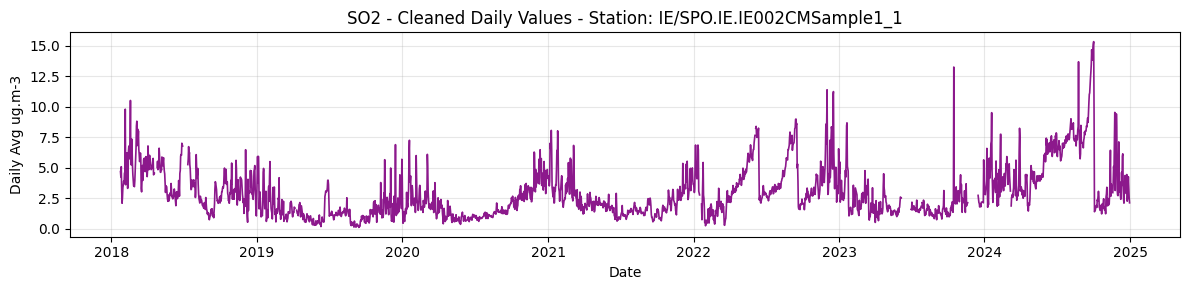

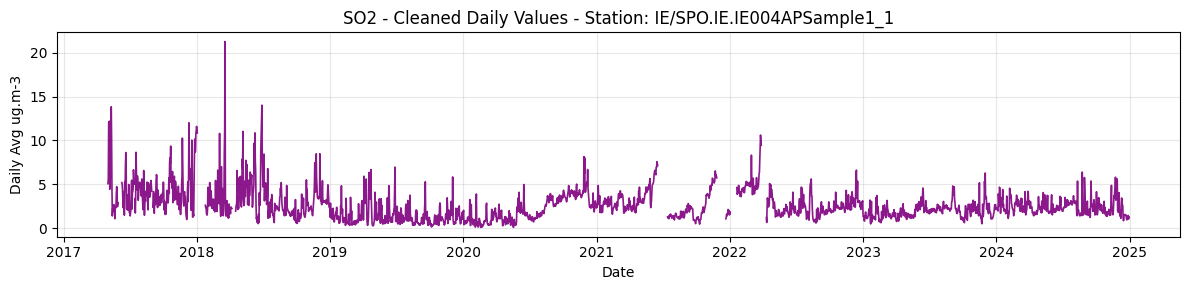

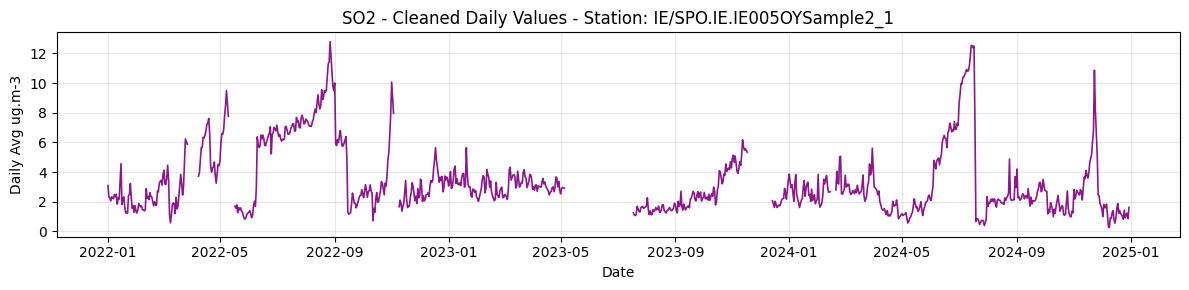

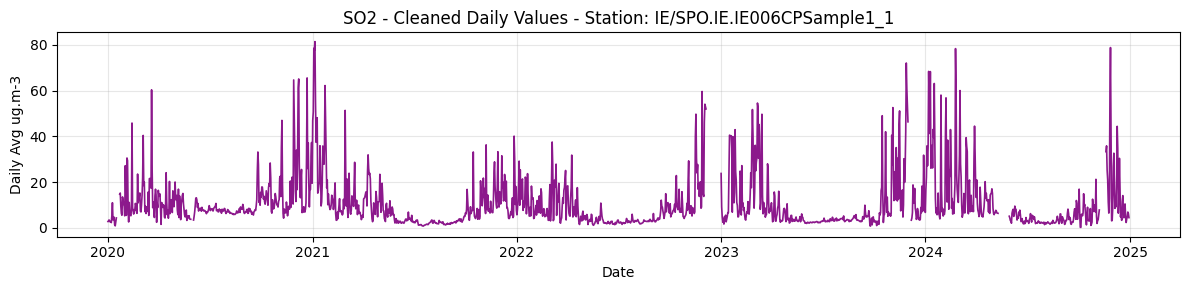

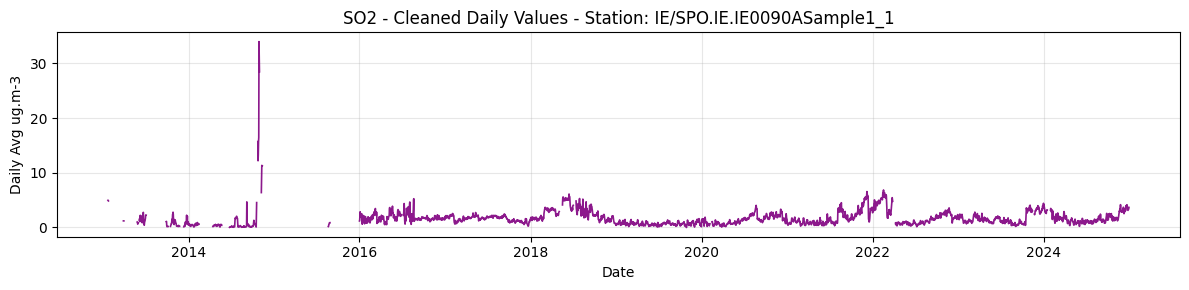

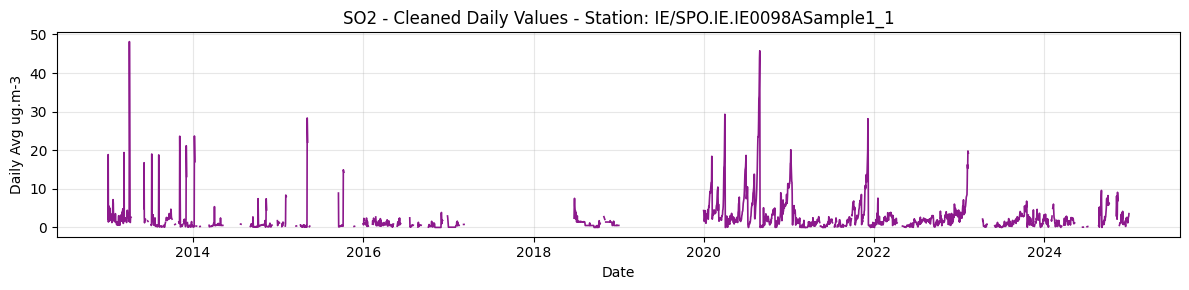

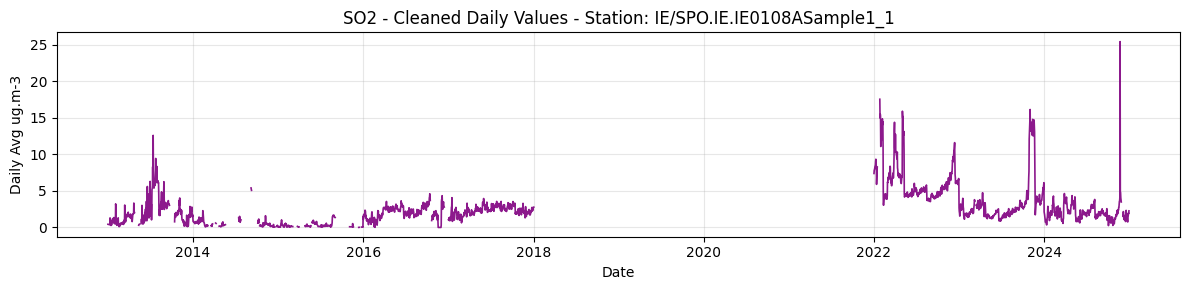

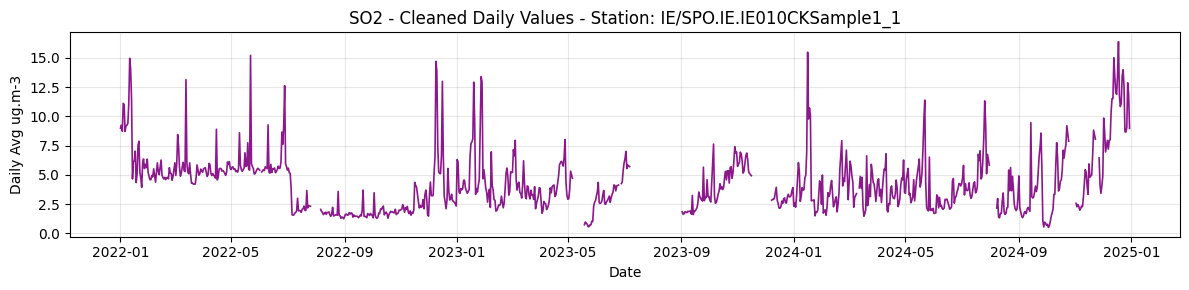

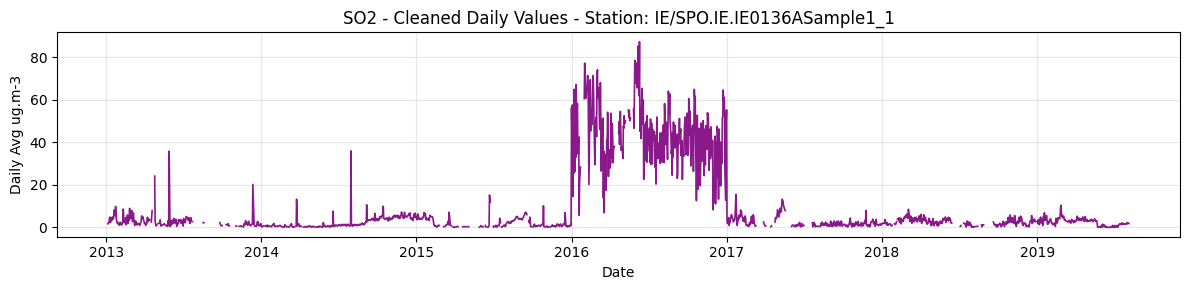

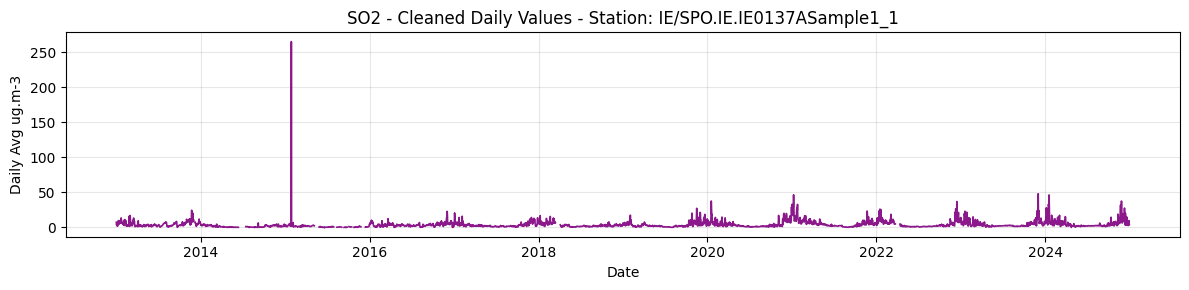

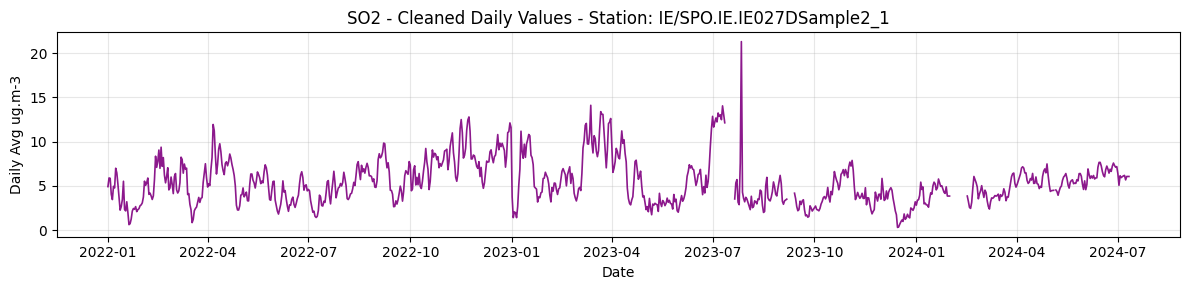

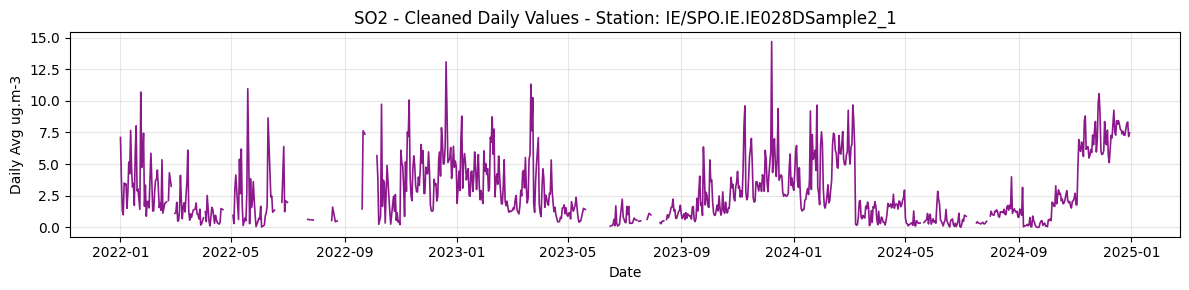

In [27]:
plot_dir = output_dir / "Cleaned_Daily_Plots"
plot_dir.mkdir(parents=True, exist_ok=True)

stations = df_daily_Final['Samplingpoint'].unique()

for station in stations:
    station_data = df_daily_Final[df_daily_Final['Samplingpoint'] == station]
    
    plt.figure(figsize=(12, 3))
    plt.plot(station_data['Start'], station_data['Value'], color='purple', alpha=0.9, linewidth=1.2)
    plt.title(f'{POLLUTANT} - Cleaned Daily Values - Station: {station}')
    plt.ylabel('Daily Avg ug.m-3')
    plt.xlabel('Date')
    plt.grid(True, alpha=0.3)
    clean_station_name = str(station).replace(".", "_").replace("/", "_")
    file_name = f"{COUNTRY_CODE}_{POLLUTANT}_{clean_station_name}_cleanData_Daily.png"
    plt.savefig(plot_dir / file_name, dpi=150) # Save it to the new folder
    plt.tight_layout()
    plt.show()
    plt.close()